In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import random



import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
import os
import random


In [17]:
# Define directories
base_dir = r'C:\Users\vaibh\OneDrive\Desktop\Vaibhav_project\Vaibhav_project\explicit_dataset' # Update this path according to your dataset
categories = ['healthy', 'iron_deficient', 'kidney_disease', 'melanoma']

# Image dimensions
IMG_SIZE = 224  # ResNet50 expects input size of 224x224

def load_images(base_dir, categories, img_size):
    data = []
    for category in categories:
        path = os.path.join(base_dir, category)
        class_num = categories.index(category)  # Label assignment
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append([resized_img, class_num])
            except Exception as e:
                pass
    return data

data = load_images(base_dir, categories, IMG_SIZE)

# Shuffle data
random.shuffle(data)

# Prepare features (X) and labels (y)
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3) / 255.0  # Normalize
y = np.array(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [21]:
# Load the pre-trained ResNet50 model
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the base layers of ResNet50 so that they don’t get updated during training
for layer in resnet.layers:
    layer.trainable = False

# Create a new model with ResNet50 as the base and custom top layers
model = Sequential([
    resnet,  # Use ResNet50 as the base model
    GlobalAveragePooling2D(),  # Replace Flatten with GlobalAveragePooling for better performance
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 output classes: healthy, iron deficient, kidney disease, melanoma
])


In [23]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [25]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=32), validation_data=(X_test, y_test), epochs=50)


C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.3282 - loss: 1.6684 - val_accuracy: 0.3812 - val_loss: 1.3486
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2795 - loss: 1.4068 - val_accuracy: 0.3688 - val_loss: 1.3427
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3278 - loss: 1.3664 - val_accuracy: 0.3812 - val_loss: 1.3243
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3502 - loss: 1.3468 - val_accuracy: 0.3812 - val_loss: 1.3220
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3462 - loss: 1.3332 - val_accuracy: 0.3187 - val_loss: 1.3261
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3321 - loss: 1.3480 - val_accuracy: 0.3812 - val_loss: 1.3219
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3538 - loss: 1.3431 - val_accuracy: 0.3750 - val_loss: 1.3124
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3644 - loss: 1.3508 - val_accuracy: 0.5188 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Classification Report:
                 precision    recall  f1-score   support

       healthy       0.84      0.67      0.74        48
iron_deficient       0.00      0.00      0.00        36
kidney_disease       0.00      0.00      0.00        15
      melanoma       0.46      0.92      0.61        61

      accuracy                           0.55       160
     macro avg       0.33      0.40      0.34       160
  weighted avg       0.43      0.55      0.46       160



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


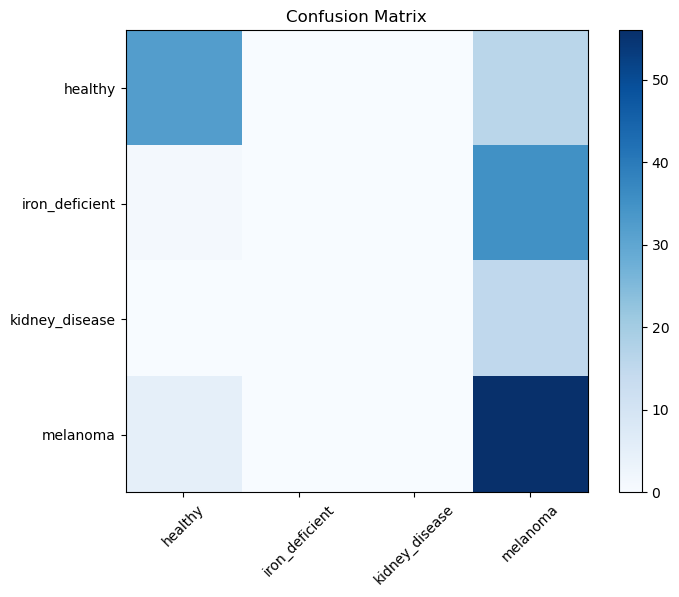

In [27]:
# Make predictions on the test set
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Print classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=categories))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(categories)), categories, rotation=45)
plt.yticks(np.arange(len(categories)), categories)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


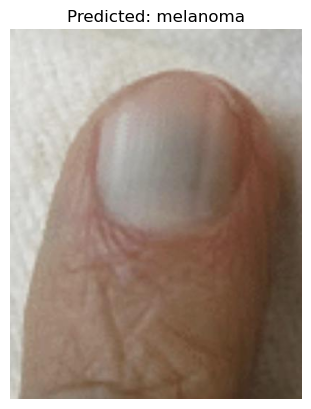

'melanoma'

In [29]:
def predict_nail_image(model, img_path, img_size, categories):
    img_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img_resized = cv2.resize(img_array, (img_size, img_size)) / 255.0
    img_reshaped = np.reshape(img_resized, (1, img_size, img_size, 3))  # Reshape for the model
    prediction = model.predict(img_reshaped)
    predicted_class = np.argmax(prediction)
    predicted_category = categories[predicted_class]

    # Display the image and prediction
    plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {predicted_category}")
    plt.axis('off')
    plt.show()

    return predicted_category

# Test the model on a specific image
img_path =r"C:\Users\vaibh\OneDrive\Desktop\Vaibhavproject\Vaibhav_project\CNN_dataset\kidney_disease\Screen-Shot-2021-10-15-at-10-36-19-AM_png_jpg.rf.0bc2dd077f0217c678b9bba81aee4782.jpg"  # Replace with the path to the image you want to test
predict_nail_image(model, img_path, IMG_SIZE, categories)


In [31]:
# Save the trained model to a file
model.save('resnet_nail_classification_model.h5')


In [33]:
# Load the saved model
from tensorflow.keras.models import load_model

loaded_model = load_model('resnet_nail_classification_model.h5')


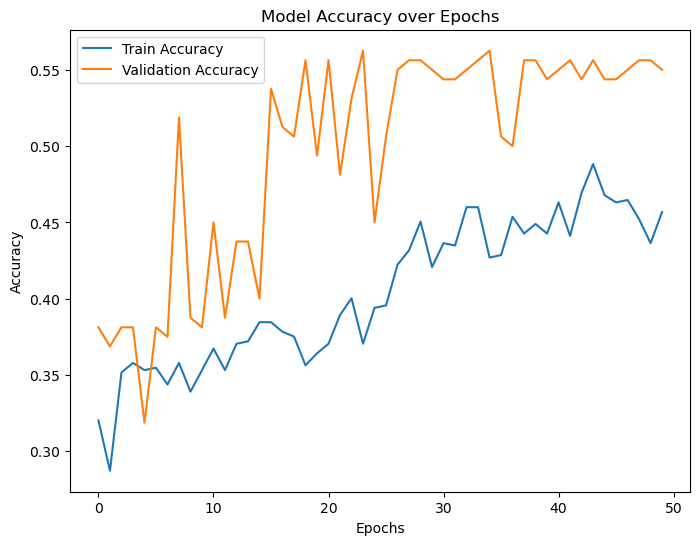

In [35]:
def plot_accuracy(history):
    plt.figure(figsize=(8, 6))
    
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    
    plt.title('Model Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left')
    
    plt.show()

# Call the function to plot accuracy
plot_accuracy(history)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import os
import random

In [38]:
from tensorflow.keras.models import load_model

loaded_model = load_model('resnet_nail_classification_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


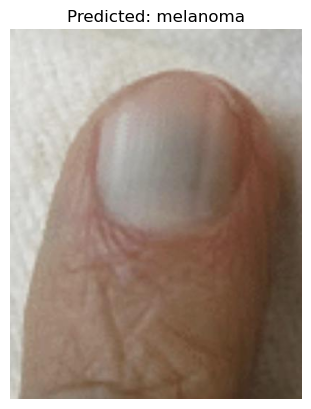

'melanoma'

In [40]:
categories = ['healthy', 'iron_deficient', 'kidney_disease', 'melanoma']
IMG_SIZE = 224  # Updated to match ResNet50 input

def predict_nail_image(model, img_path, img_size, categories):
    img_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img_resized = cv2.resize(img_array, (img_size, img_size)) / 255.0
    img_reshaped = np.reshape(img_resized, (1, img_size, img_size, 3))  # Reshape for the model
    prediction = model.predict(img_reshaped)
    predicted_class = np.argmax(prediction)
    predicted_category = categories[predicted_class]

    # Display the image and prediction
    plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {predicted_category}")
    plt.axis('off')
    plt.show()

    return predicted_category

# Test the model
img_path = r"C:\Users\vaibh\OneDrive\Desktop\Vaibhavproject\Vaibhav_project\CNN_dataset\kidney_disease\Screen-Shot-2021-10-15-at-10-36-19-AM_png_jpg.rf.0bc2dd077f0217c678b9bba81aee4782.jpg"
predict_nail_image(loaded_model, img_path, IMG_SIZE, categories)
